# Build Reference Cohort

**Purpose:** build the ONE fixed sample set and ONE fixed set of stratified cross-validation folds that every downstream experiment

**workflow**
1. Loads RNA-seq and methylation feature files and the survival file
2. Finds the sample intersection across all three
3. Builds stratified K-fold CV assignments (stratified on the OS event indicator) on this common set
4. Saves the outcome to reference_cohort folder

## 1. Imports

In [12]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

pd.set_option("display.max_columns", 20)


## 2. Configuration


In [ ]:
EXPRESSION_FILE   = "preprocessed_multiomics/expression_filtered.csv"
METHYLATION_FILE  = "preprocessed_multiomics/methylation_filtered.csv"
CLINICAL_FILE     = "preprocessed_multiomics/clinical_outcome.csv"

OUTPUT_DIR = "reference_cohort"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ENDPOINT_EVENT = "OS"
ENDPOINT_TIME  = "OS.time"

N_FOLDS = 5
RANDOM_STATE = 42

## 3. Load each layer and the survival endpoint

Only the sample index matters here, checking coverage

In [14]:
expr = pd.read_csv(EXPRESSION_FILE, index_col=0)
print(f"Expression: {expr.shape[0]} samples x {expr.shape[1]} features")

meth = pd.read_csv(METHYLATION_FILE, index_col=0)
print(f"Methylation: {meth.shape[0]} samples x {meth.shape[1]} features")

clin = pd.read_csv(CLINICAL_FILE, index_col=0)
clin = clin[[ENDPOINT_EVENT, ENDPOINT_TIME]].dropna()
clin = clin[(clin[ENDPOINT_EVENT].astype(str) != "") & (clin[ENDPOINT_TIME].astype(str) != "")]
clin[ENDPOINT_EVENT] = clin[ENDPOINT_EVENT].astype(int)
clin[ENDPOINT_TIME] = clin[ENDPOINT_TIME].astype(float)
print(f"Clinical (valid {ENDPOINT_EVENT}/{ENDPOINT_TIME}): {clin.shape[0]} samples")

additional_layers = {}
for name, path in ADDITIONAL_REQUIRED_FILES.items():
    df = pd.read_csv(path, index_col=0)
    additional_layers[name] = df
    print(f"{name}: {df.shape[0]} samples x {df.shape[1]} features")


Expression: 318 samples x 5000 features
Methylation: 318 samples x 5000 features
Clinical (valid OS/OS.time): 318 samples


## 4. Find the common sample size across ALL layers

In [15]:
common_samples = set(expr.index) & set(meth.index) & set(clin.index)
for name, df in additional_layers.items():
    common_samples &= set(df.index)
common_samples = sorted(common_samples)

print(f"Expression alone:  {expr.shape[0]} samples")
print(f"Methylation alone: {meth.shape[0]} samples")
print(f"Clinical alone:    {clin.shape[0]} samples")
print(f"\n>>> Common to ALL layers: {len(common_samples)} samples <<<")
print("\nThis is the fixed reference cohort for every downstream experiment.")


Expression alone:  318 samples
Methylation alone: 318 samples
Clinical alone:    318 samples

>>> Common to ALL layers: 318 samples <<<

This is the fixed reference cohort for every downstream experiment.


## 5. Check event rate for common cohort

In [ ]:
clin_common = clin.loc[common_samples]

n_events = clin_common[ENDPOINT_EVENT].sum()
n_total = clin_common.shape[0]
print(f"Reference cohort: {n_total} samples, {n_events} events ({n_events/n_total:.1%})")


Reference cohort: 318 samples, 104 events (32.7%)


## 6. Build fixed stratified cross-validation folds

Stratified on the OS event indicator, so each fold has a comparable death/censoring ratio.

In [17]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

folds = pd.Series(index=common_samples, dtype=int, name="fold")
for fold_idx, (_, test_idx) in enumerate(skf.split(common_samples, clin_common[ENDPOINT_EVENT].values)):
    folds.iloc[test_idx] = fold_idx

fold_report = pd.DataFrame({ENDPOINT_EVENT: clin_common[ENDPOINT_EVENT], "fold": folds})
event_by_fold = fold_report.groupby("fold")[ENDPOINT_EVENT].agg(["count", "sum"]).rename(
    columns={"count": "n_samples", "sum": "n_events"})
event_by_fold


,n_samples,n_events
fold,,
0.0,64,21
1.0,64,21
2.0,64,21
3.0,63,20
4.0,63,21


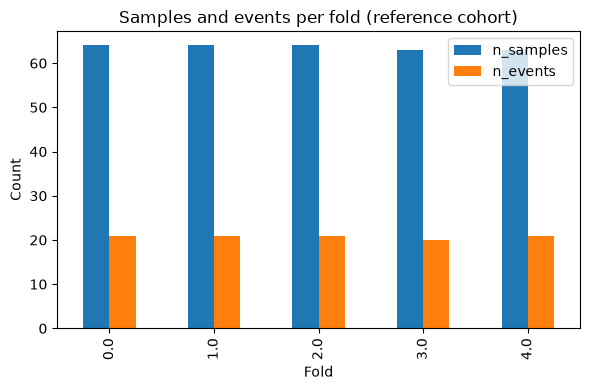

In [18]:
import matplotlib.pyplot as plt

event_by_fold.plot(kind="bar", figsize=(6, 4))
plt.title("Samples and events per fold (reference cohort)")
plt.ylabel("Count")
plt.xlabel("Fold")
plt.tight_layout()
plt.show()


## 7. Save the reference cohort artifacts

will be loaded via `common_utils.load_reference_cohort()` during downstream analysis

In [ ]:
clin_common.to_csv(os.path.join(OUTPUT_DIR, "clinical_outcome.csv"))
folds.to_csv(os.path.join(OUTPUT_DIR, "cv_folds.csv"), header=True)

#saving plain sample list, for quick sanity-checks if needed later
pd.Series(common_samples, name="sample").to_csv(
    os.path.join(OUTPUT_DIR, "reference_samples.csv"), index=False)

print(f"Saved to {OUTPUT_DIR}/:")
print("  clinical_outcome.csv    -> sample, OS, OS.time (reference cohort only)")
print("  cv_folds.csv            -> sample, fold (fixed assignment, reuse everywhere)")
print("  reference_samples.csv   -> plain list of the reference cohort's sample IDs")


Saved to reference_cohort/:
  clinical_outcome.csv    -> sample, OS, OS.time (reference cohort only)
  cv_folds.csv            -> sample, fold (fixed assignment, reuse everywhere)
  reference_samples.csv   -> plain list of the reference cohort's sample IDs


: 

## Summary

| | |
|---|---|
| Reference cohort size | 318 |
| Event rate | 32.7% |
| CV folds | 5, stratified on OS event |